# [3장 1강] - 실습: 고유값과 고유벡터

**실습 목표**
- `Av = λv`를 코드로 검증해 고유벡터가 방향이 보존되는 벡터임을 확인할 수 있다.
- 특성방정식 `det(A - λI) = 0`이 성립함을 수치적으로 확인할 수 있다.
- 대칭행렬의 고유값이 실수이고 고유벡터가 서로 직교함을 검증할 수 있다.
- 고유값이 해당 방향의 분산 크기를 나타냄을 데이터로 해석할 수 있다.

- 작은 행렬로 정의 확인 → 실제 데이터 공분산행렬 고유분해 → 고유값의 의미 해석 순서로 진행합니다.
- 개인 실습으로 진행하며, 정의(`Av = λv`)를 항상 코드로 직접 검증한 뒤 다음 단계로 넘어갑니다.

**실습에 필요한 데이터셋/파일**
- 분야: 헬스케어
- 데이터셋: UCI Breast Cancer Wisconsin (Diagnostic)
- 사용 방식: `ucimlrepo.fetch_ucirepo(id=17)`
- 출처: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- 사용 목적: 진단 특성들의 공분산행렬(대칭행렬)을 고유분해해 데이터가 퍼져 있는 방향과 그 크기를 확인합니다.
- 준비물: Python, NumPy, pandas, matplotlib, scikit-learn, ucimlrepo

- 고유분해는 **정사각행렬에만** 적용할 수 있습니다. 데이터 행렬 `X`는 보통 정사각이 아니므로, 정사각이면서 대칭인 공분산행렬을 만들어 사용합니다.
- 특성마다 단위가 다르면 스케일이 큰 항목이 공분산을 독점합니다. 공분산행렬을 만들기 전에 **표준화**를 먼저 적용합니다.
- `np.cov(..., rowvar=False)`는 기본적으로 표본 공분산(`ddof=1`)을 계산합니다. 이후 분산과 비교할 때도 `ddof=1`로 맞춰야 값이 일치합니다.

In [2]:
# 최초 1회만 실행 (새 환경일 때)
# !pip -q install ucimlrepo scikit-learn pandas numpy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def load_uci(dataset_id):
    """UCI에서 데이터를 불러오고, 실패하면 구조가 비슷한 대체 데이터를 사용합니다."""
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=dataset_id)
        X, y = ds.data.features.copy(), ds.data.targets.copy()
        if isinstance(y, pd.DataFrame) and y.shape[1] == 1:
            y = y.iloc[:, 0]
        return X, y
    except Exception as e:
        print('[안내] UCI 로드 실패:', e)
        print('[안내] 대체 데이터(sklearn breast cancer)로 진행합니다.')
        from sklearn.datasets import load_breast_cancer
        data = load_breast_cancer(as_frame=True)
        return data.data, data.target


def numeric_frame(X):
    """수치형 컬럼만 남기고 결측값을 중앙값으로 채웁니다."""
    Xn = X.select_dtypes(include='number').copy()
    Xn = Xn.replace([np.inf, -np.inf], np.nan)
    return Xn.fillna(Xn.median(numeric_only=True))


X_raw, y_raw = load_uci(17)   # Breast Cancer Wisconsin
Xs = StandardScaler().fit_transform(numeric_frame(X_raw))
cov = np.cov(Xs, rowvar=False)      # 대칭이며 정사각인 행렬
print('표준화 데이터:', Xs.shape, '/ 공분산행렬:', cov.shape)

표준화 데이터: (569, 30) / 공분산행렬: (30, 30)


## 필수 1 : 변환을 통과해도 방향이 바뀌지 않는 벡터 찾기
행렬은 벡터를 다른 벡터로 옮기는 변환입니다. 대부분의 벡터는 변환을 거치면 방향과 길이가 모두 바뀌지만, 어떤 행렬에는 방향은 그대로이고 길이만 변하는 특별한 벡터가 있습니다. 이 벡터를 찾으면 그 변환이 "어느 방향으로 얼마나 작용하는지"를 축 단위로 분해해 이해할 수 있습니다. 작은 행렬로 정의부터 정확히 확인합니다.

### 문제 1-1 : Av = λv 검증하기
1. 행렬 `A = [[4, 2], [1, 3]]`을 정의하고 `np.linalg.eig`로 고유값과 고유벡터를 구합니다.
2. 첫 번째 고유값 `λ1`과 고유벡터 `v1`에 대해 `A @ v1`과 `λ1 * v1`을 각각 계산해 값이 같은지 확인합니다.
3. 두 번째 고유값·고유벡터에 대해서도 동일하게 확인합니다.
4. 고유벡터 `v1`을 3배 한 벡터 `3 * v1`도 `A(3v1) = λ1(3v1)`을 만족하는지 확인합니다.
5. 고유벡터가 "방향"으로만 의미를 갖는 이유를 한 문장으로 설명합니다.

In [3]:
# 1. 행렬 `A = [[4, 2], [1, 3]]`을 정의하고 `np.linalg.eig`로 고유값과 고유벡터를 구합니다.
A = np.array([
    [4, 2],
    [1, 3]
])

# det(A−λI)=0
# 튜플로 (고유값 배열, 고유벡터 행렬)을 돌려줌
# eigenvectors의 각 열(column)이 하나의 고유벡터

eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"eigenvalues: \n{eigenvalues}\n")
print(f"eigenvectors: \n{eigenvectors}\n")

# 2. 첫 번째 고유값 `λ1`과 고유벡터 `v1`에 대해 `A @ v1`과 `λ1 * v1`을 각각 계산해 값이 같은지 확인합니다.
v1 = eigenvectors[:, 0]
v2 = eigenvectors[:, 1]
w1 = eigenvalues[0]
w2 = eigenvalues[1]
# print(v1, v2, w1, w2)
print(f"A @ v1 = {A @ v1}")
print(f"λ1 * v1 = {w1 * v1}\n")

# 3. 두 번째 고유값·고유벡터에 대해서도 동일하게 확인합니다.
print(f"A @ v2 = {A @ v2}")
print(f"λ2 * v2 = {w2 * v2}\n")

# 4. 고유벡터 `v1`을 3배 한 벡터 `3 * v1`도 `A(3v1) = λ1(3v1)`을 만족하는지 확인합니다.
print(f"A @ (3 * v1) = {A @ (3 * v1)}")
print(f"λ1 * (3 * v1) = {w1 * (3 * v1)}\n")

# 5. 고유벡터가 "방향"으로만 의미를 갖는 이유를 한 문장으로 설명합니다.
# 고유벡터는 크기가 자유롭고 방향만 의미가 있기 때문에, 0이 아닌 모든 스칼라배가 전부 같은 고유값의 고유벡터이다.

eigenvalues: 
[5.+0.j 2.+0.j]

eigenvectors: 
[[ 0.89442719+0.j -0.70710678+0.j]
 [ 0.4472136 +0.j  0.70710678+0.j]]

A @ v1 = [4.47213595+0.j 2.23606798+0.j]
λ1 * v1 = [4.47213595+0.j 2.23606798+0.j]

A @ v2 = [-1.41421356+0.j  1.41421356+0.j]
λ2 * v2 = [-1.41421356+0.j  1.41421356+0.j]

A @ (3 * v1) = [13.41640786+0.j  6.70820393+0.j]
λ1 * (3 * v1) = [13.41640786+0.j  6.70820393+0.j]



### 문제 1-2 : 특성방정식과 일반 벡터 비교하기
1. 각 고유값 `λ`에 대해 `det(A - λI)`를 계산해 0에 가까운지 확인합니다.
2. 고유값이 아닌 임의의 값(예: 3.0)에 대해서도 `det(A - λI)`를 계산해 0이 아님을 확인합니다. `A`의 고유값은 5와 2이므로 2.0을 넣으면 `det`가 0이 되어 버려 반례가 되지 않습니다. 반례로 쓸 값은 **고유값 목록에 없는 값**이어야 합니다.
3. 고유벡터가 아닌 벡터 `u = [1, 0]`에 `A`를 적용하고, 적용 전후의 방향(정규화한 벡터)을 비교합니다.
4. 고유벡터 `v1`에 대해서도 같은 비교를 해 방향이 유지되는지 확인합니다.
5. 특성방정식이 왜 고유값을 찾는 식이 되는지 한 문장으로 설명합니다.

In [4]:
# 1. 각 고유값 `λ`에 대해 `det(A - λI)`를 계산해 0에 가까운지 확인합니다.
det1 = np.linalg.det(A - (w1 * np.eye(2)))
det2 = np.linalg.det(A - (w2 * np.eye(2)))
print(det1, det2)
print(f"np.isclose(det1, 0): {np.isclose(det1, 0)}")
print(f"np.isclose(det2, 0): {np.isclose(det2, 0)}")

# 2. 고유값이 아닌 임의의 값(예: 3.0)에 대해서도 `det(A - λI)`를 계산해 0이 아님을 확인합니다. `A`의 고유값은 5와 2이므로 2.0을 넣으면 `det`가 0이 되어 버려 반례가 되지 않습니다. 반례로 쓸 값은 **고유값 목록에 없는 값**이어야 합니다.
print(f"고유값이 아닌 임의의 값의 특성방정식 값: {np.linalg.det(A - (3 * np.eye(2)))}")

# 3. 고유벡터가 아닌 벡터 `u = [1, 0]`에 `A`를 적용하고, 적용 전후의 방향(정규화한 벡터)을 비교합니다.
u = np.array([1, 0])
u_dir = u / np.linalg.norm(u)
Au = A @ u
Au #array([4, 1])
Au_dir = Au / np.linalg.norm(Au)
print(f"u의 방향: {u_dir}, Au의 방향: {Au_dir}")

# 4. 고유벡터 `v1`에 대해서도 같은 비교를 해 방향이 유지되는지 확인합니다.
v1_dir = v1 / np.linalg.norm(v1)
Av1_dir = A @ v1 / np.linalg.norm(A @ v1)
print(f"v1의 방향: {v1_dir}, Av1의 방향: {Av1_dir}")

# 5. 특성방정식이 왜 고유값을 찾는 식이 되는지 한 문장으로 설명합니다.
# Av = λv -> Av - λv = 0 -> (A - λ)v = 0 -> (A - λ)를 M이라는 변수로 치환하면 Mv = 0 -> M이 역행렬이 있다고 가정하고 좌변 우변에 역행렬을 곱하면 v = 0 이 된다.
# v = 0을 만족하지 않는 전제를 조건으로 하고 있기 떄문에 M, 즉 (A - λ)는 역행렬이 존재해서는 안 된다. 즉 det(A - λ)=0이 되어야 한다. 

0j 0j
np.isclose(det1, 0): True
np.isclose(det2, 0): True
고유값이 아닌 임의의 값의 특성방정식 값: -2.0
u의 방향: [1. 0.], Au의 방향: [0.9701425  0.24253563]
v1의 방향: [0.89442719+0.j 0.4472136 +0.j], Av1의 방향: [0.89442719+0.j 0.4472136 +0.j]


## 필수 2 : 진단 데이터가 실제로 퍼져 있는 방향 찾기
진단 지표가 30개인 데이터에서는 어떤 지표들이 함께 움직이는지 한눈에 보이지 않습니다. 지표 간 관계를 담은 공분산행렬을 고유분해하면, 데이터가 퍼져 있는 주된 방향들을 서로 겹치지 않게 뽑아낼 수 있습니다. 공분산행렬은 대칭행렬이므로 계산이 안정적으로 보장된다는 점도 함께 확인합니다.

### 문제 2-1 : 공분산행렬 고유분해하기
1. `cov`가 대칭행렬인지 `np.allclose(cov, cov.T)`로 확인합니다. 부동소수점 연산 결과는 미세한 오차를 남기므로 `==`나 `(cov == cov.T).all()`로 비교하면 실제로 대칭인 행렬도 `False`가 나올 수 있습니다.
2. `np.linalg.eigh(cov)`로 고유값과 고유벡터를 구합니다.
3. 고유값을 **내림차순으로 정렬**하고 고유벡터의 열 순서도 함께 맞춥니다.
4. 상위 5개 고유값과 전체 고유값의 합을 출력합니다.
5. 고유값이 모두 실수이고 0 이상인지 확인하고, 그것이 공분산행렬의 어떤 성질에서 오는지 설명합니다.

In [5]:
# 1. `cov`가 대칭행렬인지 `np.allclose(cov, cov.T)`로 확인합니다. 부동소수점 연산 결과는 미세한 오차를 남기므로 `==`나 `(cov == cov.T).all()`로 비교하면 실제로 대칭인 행렬도 `False`가 나올 수 있습니다.
# print(Xs.shape) #(569, 30)
Xs_cov = Xs.T @ Xs
# print(Xs_cov.shape) #(30, 30)
# print(np.allclose(Xs_cov, Xs_cov.T)) #True

# 2. `np.linalg.eigh(cov)`로 고유값과 고유벡터를 구합니다.
cov_w = np.linalg.eigh(Xs_cov)[0]
cov_v = np.linalg.eigh(Xs_cov)[1]
# print(cov_w)

# 3. 고유값을 **내림차순으로 정렬**하고 고유벡터의 열 순서도 함께 맞춥니다.
order = np.argsort(-cov_w)
cov_w_sorted = cov_w[order]
# print(cov_w_sorted)
cov_v_sorted = cov_v[:, order]

# 4. 상위 5개 고유값과 전체 고유값의 합을 출력합니다.
print(cov_w_sorted[0:5])
print(np.sum(cov_w_sorted))

# 5. 고유값이 모두 실수이고 0 이상인지 확인하고, 그것이 공분산행렬의 어떤 성질에서 오는지 설명합니다.
print(cov_w_sorted.dtype)
print(np.all(cov_w_sorted > 0))

[7557.2347712  3238.38077492 1603.41296804 1126.98443007  938.12768164]
17069.999999999996
float64
True


### 문제 2-2 : 고유벡터의 직교성과 eig/eigh 비교하기
1. 상위 두 고유벡터의 내적을 계산해 0에 가까운지 확인합니다.
2. 고유벡터 행렬 `V`에 대해 `VᵀV`가 단위행렬인지 확인합니다.
3. 같은 공분산행렬을 `np.linalg.eig`로도 분해해, 고유벡터 행렬의 **직교성 오차**(`max|VᵀV − I|`)를 `eigh` 결과와 비교합니다.
4. 두 방식의 고유값이 **정렬되어 나오는지** 각각 확인하고(`eigh`는 오름차순을 보장하지만 `eig`는 보장하지 않습니다), 정렬을 맞춘 뒤 값 차이를 확인합니다.
5. 대칭행렬에 `eigh`를 사용해야 하는 이유를 한 문장으로 작성합니다.

In [6]:
# 1. 상위 두 고유벡터의 내적을 계산해 0에 가까운지 확인합니다.
inner_product = cov_v_sorted[:, 0] @ cov_v_sorted[:, 1]
print(f"고유벡터의 내적 == 0 : {np.isclose(inner_product, 0)}")

# 2. 고유벡터 행렬 `V`에 대해 `VᵀV`가 단위행렬인지 확인합니다.
# print(cov_v.T @ cov_v)
print(f"고유벡터 행렬 V의 VTV가 단위행렬인지: {np.allclose(cov_v.T @ cov_v, np.eye(30))}")

# 3. 같은 공분산행렬을 `np.linalg.eig`로도 분해해, 고유벡터 행렬의 **직교성 오차**(`max|VᵀV − I|`)를 `eigh` 결과와 비교합니다.
# Xs_cov = Xs.T @ Xs
# cov_w = np.linalg.eigh(Xs_cov)[0]
# cov_v = np.linalg.eigh(Xs_cov)[1]

# 기존: eigh 결과 (대칭 전용)
w_h, V_h = np.linalg.eigh(Xs_cov)

# 추가: eig 결과 (범용) — 같은 Xs_cov를 넣음
w_e, V_e = np.linalg.eig(Xs_cov)

# 두 결과의 직교성 오차 비교
err_eigh = np.max(np.abs(V_h.T @ V_h - np.eye(30)))
err_eig  = np.max(np.abs(V_e.T @ V_e - np.eye(30)))

print(f"eigh 오차: {err_eigh}")
print(f"eig  오차: {err_eig}")

# 4. 두 방식의 고유값이 **정렬되어 나오는지** 각각 확인하고(`eigh`는 오름차순을 보장하지만 `eig`는 보장하지 않습니다), 정렬을 맞춘 뒤 값 차이를 확인합니다.
print(np.argsort(w_h))
print(np.argsort(w_e))

# 5. 대칭행렬에 `eigh`를 사용해야 하는 이유를 한 문장으로 작성합니다. 
# eigh는 대칭행렬 전용이라 고유벡터의 직교성이 잘 유지되며 정보가 겹침없이 나뉜다.

고유벡터의 내적 == 0 : True
고유벡터 행렬 V의 VTV가 단위행렬인지: True
eigh 오차: 2.1094237467877974e-15
eig  오차: 2.2435206266396756e-13
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
[19 20 21 22 23 24 25 26 27 29 28 18 17 16 15 14 13 12 11 10  9  8  7  6
  5  4  3  2  1  0]


## 심화 1 : 고유값은 그 방향의 분산 크기다
고유값이 크다는 말이 실제 데이터에서 무엇을 의미하는지 확인해야 다음 강의의 PCA를 이해할 수 있습니다. 첫 번째 고유벡터 방향으로 데이터를 투영한 뒤, 그 투영값의 분산이 정말 고유값과 같은지 검증합니다.

### 문제 3-1 : 투영값의 분산과 고유값 비교하기
1. 첫 번째 고유벡터 `pc1` 방향으로 데이터를 투영합니다. (`z1 = Xs @ pc1`)
2. `z1`의 분산(`ddof=1`)을 계산해 첫 번째 고유값과 비교합니다.
3. 두 번째 고유벡터 방향에 대해서도 같은 비교를 합니다.
4. 비교 대상으로, **고유벡터가 아닌 임의의 단위벡터** 방향으로 투영한 값의 분산도 계산합니다.
5. `z1`의 히스토그램을 그려 분포를 확인합니다.
6. 고유값이 큰 방향을 우선 선택하는 것이 왜 차원 축소에서 유리한지 2~3문장으로 작성합니다.

z1의 분산: 13.304990794374554, 첫 번째 고유값: 13.304990794374557
z2의 분산: 5.701374603726144, 두 번째 고유값: 5.701374603726136
u1의 분산: 1.1703492587196282
Xs 공분산행렬의 최대 고유값: 13.304990794374557


<function matplotlib.pyplot.show(close=None, block=None)>

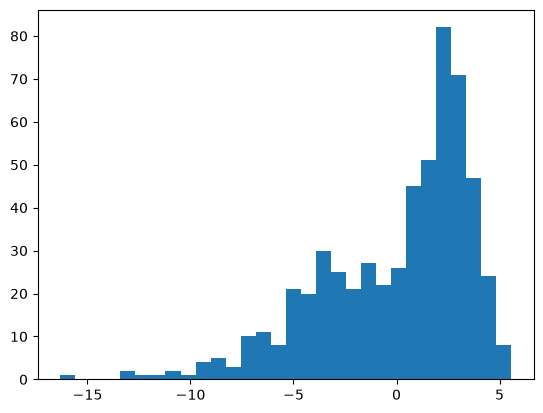

In [7]:
# 1. 첫 번째 고유벡터 `pc1` 방향으로 데이터를 투영합니다. (`z1 = Xs @ pc1`)
Xs.shape #(569, 30)
# Xs_cov = Xs.T @ Xs
Xs_cov = np.cov(Xs, rowvar=False)
Xs_cov.shape #(30, 30)
Xs_cov_V = np.linalg.eigh(Xs_cov)[1]
Xs_cov_w = np.linalg.eigh(Xs_cov)[0]
# pc1.shape # (30,)
pc1 = Xs_cov_V[:, -1]
z1 = Xs @ pc1
z1.shape # (569,)

# 2. `z1`의 분산(`ddof=1`)을 계산해 첫 번째 고유값과 비교합니다.
z1_var = np.var(z1, ddof=1)
print(f"z1의 분산: {z1_var}, 첫 번째 고유값: {Xs_cov_w[-1]}")

# 3. 두 번째 고유벡터 방향에 대해서도 같은 비교를 합니다.
pc2 = Xs_cov_V[:, -2]
z2 = Xs @ pc2
z2_var = np.var(z2, ddof=1)
print(f"z2의 분산: {z2_var}, 두 번째 고유값: {Xs_cov_w[-2]}")

# 4. 비교 대상으로, **고유벡터가 아닌 임의의 단위벡터** 방향으로 투영한 값의 분산도 계산합니다.
u = np.array(np.random.randn(30))
u = u / np.linalg.norm(u)
u1 = Xs @ u #Xs를 u에 투영
u1_var = np.var(u1, ddof=1)
print(f"u1의 분산: {u1_var}")
print(f"Xs 공분산행렬의 최대 고유값: {Xs_cov_w[-1]}")

# 5. `z1`의 히스토그램을 그려 분포를 확인합니다.
plt.hist(z1, bins=30)
plt.show

# 6. 고유값이 큰 방향을 우선 선택하는 것이 왜 차원 축소에서 유리한지 2~3문장으로 작성합니다.
# 분산이 크면 데이터들의 많은 정보를 담아낼 수 있다. 